In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm
import scipy
from sklearn.metrics import mean_squared_error
sys.path.append('../src')
from data_loader import DataLoader
from configs import MeasurementDataEnum, SetupEnum 
from filterpy.kalman import MerweScaledSigmaPoints
import scipy.stats as stats

%matplotlib inline
np.random.seed(777)

In this notebook, Unscented Kalman filter is introduced to the Kitti dataset. In Extended Kalman filter, the motion model is linearized using first-order Taylor expansion to approximate the nonlinear function about mean value of the random variable. However, uncertainty of the distribution, covariance, is not accurately reflect the actual distribution resulting in introducing large error in the true posterior mean and covariance of the transformed gaussian random variable.

Unlike KEF, the state distribution is approximated by a gaussian random variable represented by a minimal set of carefully chosen sample points (deterministic sampling approach).


- [Unscented Kalman filter description](#Unscented-Kalman-filter)
- [Load data](#Load-raw-data-0033)
- [Data visualization](#Display-data-with-noise)
- [Applying Unscented Kalman filter](#Applying-Unscented-Kalman-filter)
    - [Setup1](#Setup1-(IMU-input-->-UKF-with-Visual-Odometry-measurement))
        - [Setup1 result](#Setup1-Result)
    - [Setup2](#Setup2-(IMU-input-->-UKF-with-Visual-Odometry-and-GPS-measurement))
        - [Setup2 result](#Setup2-Result)
    - [Setup3](#Setup3-(INS-input-->-UKF-with-Visual-Odometry-and-INS-measurement))
        - [Setup3 result](#Setup3-Result)
- [Result](#Result)

## Unscented Kalman filter

Unscented Kalman filter approximate nonlinear motion model by using unscented transform instead of analytical transform that EKF performs. The unscented transformation is a method for calculating the mean and covariance of a random variable by passing it through a nonlinear function.

Like other filtering technique, Unscented Kalman filter follows the time update and measurement update steps.

In the time update step:

Suppose we have a random variable $x^{L}$, we compute a subset of points, called as sigma point, $\chi_{(i)}$, where i = 1...2L+1. Then a sigma vector $\chi$ is formed as follows:

$$\begin{align}
 \chi_{k-1}^{(i)} &= \hat{x_{k-1}} \\
 \chi_{k-1}^{(i)} &= \hat{x_{k-1}} + (\sqrt{(L+\lambda)*P_{x}})_{i}, i=1, ..., L\\
 \chi_{k-1}^{(i)} &= \hat{x_{k-1}} - (\sqrt{(L+\lambda)*P_{x}})_{i}, i=L+1, ..., 2L\\
\end{align}
$$
where, $\lambda$ is a caling parameter $\lambda = \alpha^{2}(L+k) - L$. $\alpha$ determins the spread of the sigma points around the sample mean $\hat{x}$, which is normally small positive value such as 0.001. Moreover, k is secondary scaling parameter, which is usually set to 0.

The number of sigma points required to approximate the nonlinearly transformed distribution is $2L + 1$. So, sigma points are chosen one point for the mean, and pair of points for the symetrically distributed about the mean.

Next, these sigma points are propagated through the nonlinear function:
$$\begin{align}
 \chi_{k-1}^{(i)} &= g(\chi_{k-1}^{(i)}, w_{k-1}, 0)
\end{align}
$$.

After propagation of all sigma points, sample mean and sample covariance of the propagated points are computed as follows:
$$\begin{align}
 \hat{x_{k}^{-}} &= \sum_{i=0}^{2L} W^{m}_{i}*\chi_{k-1}^{(i)}\\
 \hat{P_{x,k}} &= \sum_{i=0}^{2L} W^{c}_{i}*(\chi_{k-1}^{(i)} - \hat{x_{k}^{-}})(\chi_{k-1}^{(i)} - \hat{x_{k}^{-}})^{T} + Q_{k-1}
\end{align}
$$
where, Q is additive process noise.

In the measurement update step:

Once we obtain sample mean and covariance of propagated points, we predict measurement from the propagated sigma points.
$$\begin{align}
 z^{(i)}_{k, approx} &= h(\chi_{k-1}^{(i)}, w_{k-1}, 0)
\end{align}
$$

Finally, the approximated mean and covariance from the predicted measurements:
$$\begin{align}
 y_{k} &= \sum_{i=0}^{2L} W^{m}_{i}*z^{(i)}_{k, approx}\\
 \hat{P_{y,k}} &= \sum_{i=0}^{2L} W^{c}_{i}*(z^{(i)}_{k, approx} - y_{k})(z^{(i)}_{k, approx} - y_{k})^{T} + R_{k}
\end{align}
$$.

Besides the estimation, cross-covariance between propagated distribution and distribution of predicted measurement is computed as follows:
$$\begin{align}
 \hat{P_{xy,k}} &= \sum_{i=0}^{2L} W^{c}_{i}*(\chi_{k-1}^{(i)} - \hat{x_{k}^{-}})(z^{(i)}_{k, approx} - y^{(i)}_{k})^{T}
\end{align}
$$

Finally, Kalman gain and correction of the mean and covariance are performed as follows:
$$\begin{align}
 K_{k} &= \hat{P_{xy,k}} * \hat{P_{y,k}^{-1}}\\
 \hat{x_{k}} &= \hat{x_{k}^{-}} + K_{k}*(z_{k, actual} - y_{k})\\
 P_{k} &= \hat{P_{x,k}} - K_{k}*\hat{P_{y,k}}*K_{k}^{T}
\end{align}
$$
where $z_{k, actual}$ is sensor reading in measurement update step.


## Load raw data 0033

Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


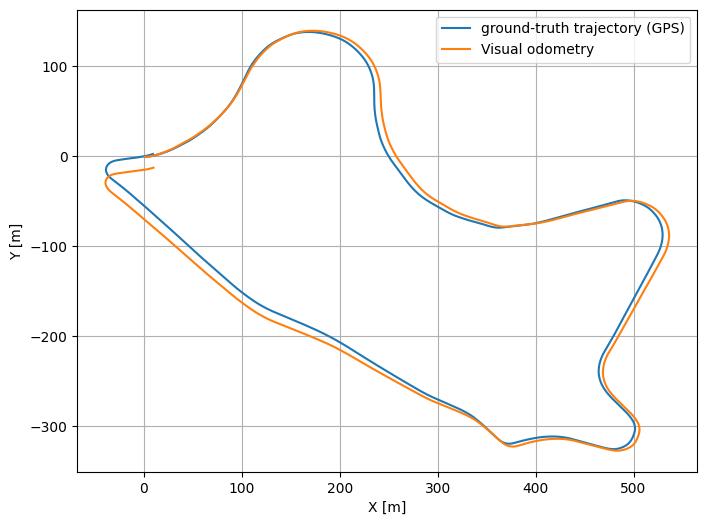

In [2]:
kitti_root_dir = '../data'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, vo_dropout_ratio=0.4, gps_dropout_ratio=0.4)

## Display data with noise

### VO trajectory with noise

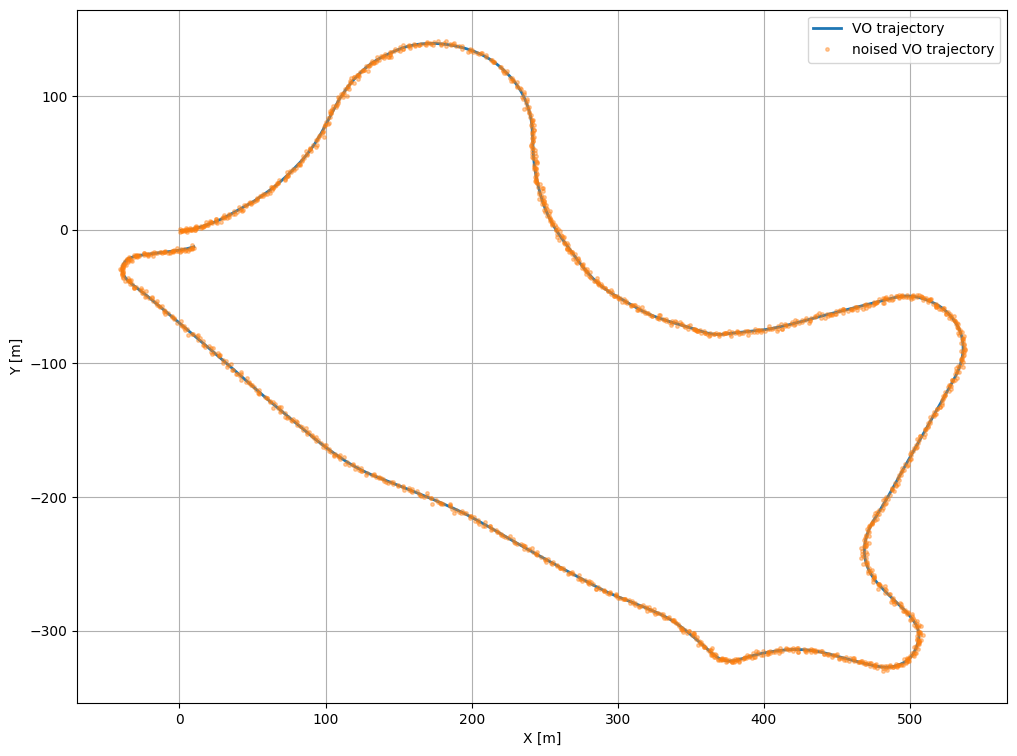

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

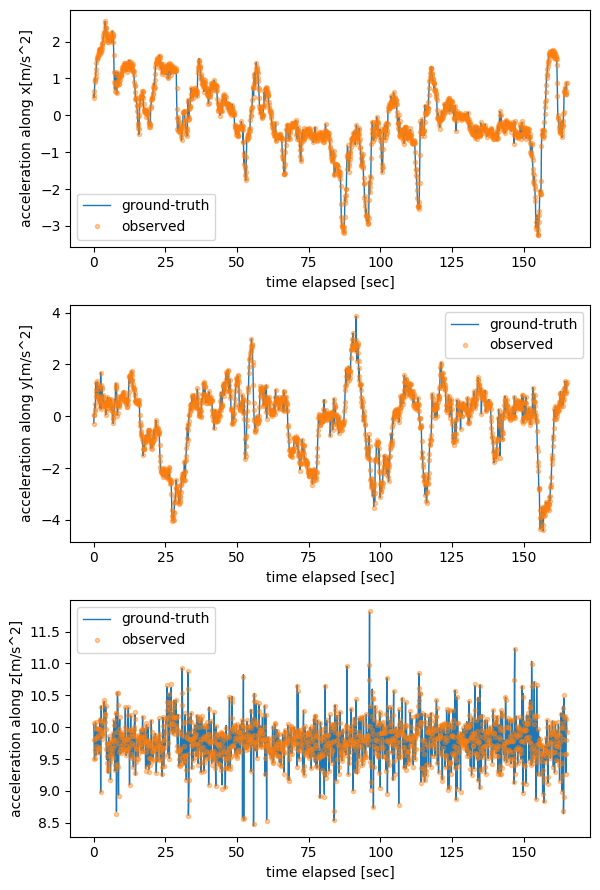

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

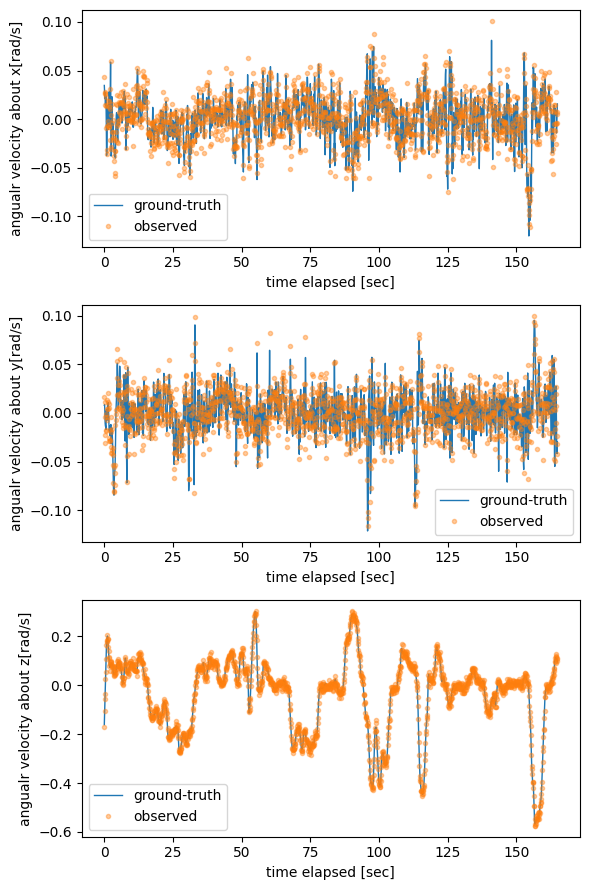

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

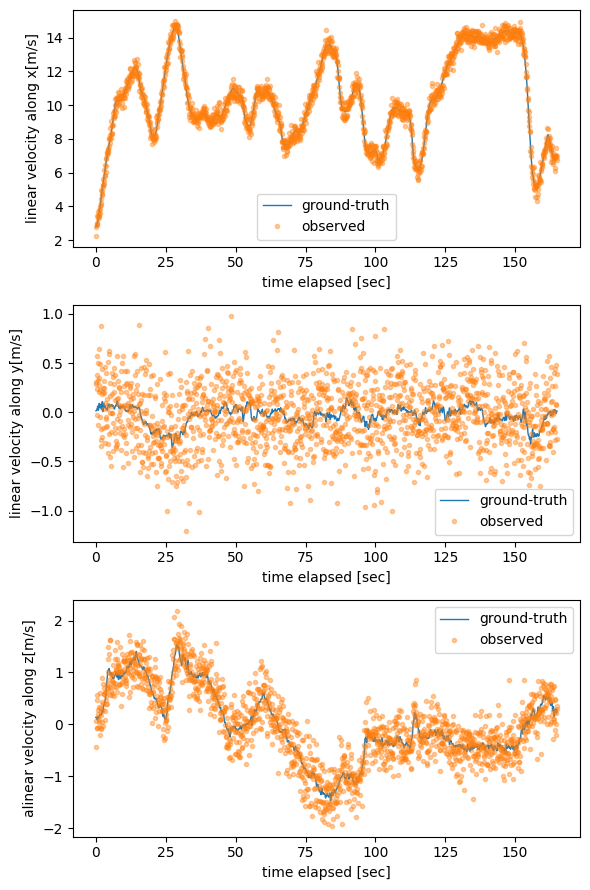

In [6]:
data.show_linear_velocity_with_noise()

# Applying Unscented Kalman filter

In [3]:
errors = []
error_vo = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :], data.VO_measurements.T[:2, :])
print(f"MSE: {error_vo}")
errors.append(error_vo)

MSE: 29.686680309859263


--------------

## Setup1 (IMU input -> EKF with Visual Odometry measurement)

In [4]:
class UnscentedKalmanFilter:

    x = None
    P = None
    sigma_points = None
    chi = None

    errors = []
    
    def __init__(self, x, P, H, alpha=1e-3, beta=2., kappa=0):
        self.N = len(x)
        self.x = x
        self.P = P
        self.H = H
        # self.lambda_ = alpha**2*(self.N + k) - self.N
        self.points = MerweScaledSigmaPoints(n=self.N, alpha=alpha, beta=beta, kappa=.1)
        self.lambda_ = 3 - self.N
        W_m0 = np.array([self.lambda_/(self.N + self.lambda_)])
        W_c0 = np.array([self.lambda_/(self.N + self.lambda_) + (1 - alpha**2 + beta)])
        W_1_N = np.array([1/(2*(self.N + self.lambda_)) for _ in range(2*self.N)])
        self.W_m = np.concatenate([W_m0, W_1_N])
        self.W_c = np.concatenate([W_c0, W_1_N])

    def compute_sigma_points(self):
        return self.points.sigma_points(self.x.reshape(-1,), self.P)
        
    def compute_norm_w(self, w):
        return np.sqrt(np.sum(w**2))

    def get_rotation_matrix(self, q):
        q1, q2, q3, q4 = q[:, 0]
        return np.array([
            [q1**2 + q2**2 - q3**2 - q4**2, 2*(q2*q3 - q1*q4), 2*(q1*q3 + q2*q4)],
            [2*(q2*q3 + q1*q4), q1**2 - q2**2 + q3**2 - q4**2, 2*(q3*q4 - q1*q2)],
            [2*(q2*q4 - q1*q3), 2*(q1*q2 + q3*q4), q1**2 - q2**2 - q3**2 + q4**2]
           ])
        
    def get_quaternion_update_matrix(self, w):
        wx, wy, wz = w[:, 0]
        return np.array([
            [0, wz, -wy, wx],
            [-wz, 0, wx, wy],
            [wy, -wx, 0, wz],
            [-wx, -wy, -wz, 0]
        ])

    def predict_setup1_2(self, u, dt, Q):

        chi = self.compute_sigma_points()
        p = chi[:, :3]
        v = chi[:, 3:6]
        q = chi[:, 6:]
        a = u[:3]
        w = u[3:]
        a = a.reshape(-1, 1)
        w = w.reshape(-1, 1)
        g = np.array([[0],[0],[9.81]])
        R = np.array([self.get_rotation_matrix(q_.reshape(-1, 1)) for q_ in q]) #21x3x3
        Omega = self.get_quaternion_update_matrix(w)
        norm_w = self.compute_norm_w(w)

        A = np.cos(norm_w*dt/2) * np.eye(4)
        B = (1/norm_w)*np.sin(norm_w*dt/2) * Omega

        acc_val = (R @ a - g)
        acc_val_reshaped = acc_val.reshape(acc_val.shape[0], acc_val.shape[1])
        p_k = p + v * dt + acc_val_reshaped*dt**2 / 2 # 21x3
        v_k = v + acc_val_reshaped * dt # 21x3
        q_k = q @ np.array(A + B) # 21x4
        
        self.chi = np.concatenate([
            p_k,
            v_k,
            q_k,
        ], axis=1) # 21x10
        

        # self.x = (self.W_m @ self.chi).reshape(-1, 1) # 10x1
        self.x = (self.points.Wm @ self.chi).reshape(-1, 1) # 10x1
        p_ = np.zeros((self.N, self.N)) # 10x10
        for i, sigma_point in enumerate(self.chi):
            p_ += self.points.Wc[i] * (sigma_point.reshape(-1, 1) - self.x) @ (sigma_point.reshape(-1, 1) - self.x).T
            # p_ += self.W_c[i] * (sigma_point.reshape(-1, 1) - self.x) @ (sigma_point.reshape(-1, 1) - self.x).T
        self.P = p_ + Q # 10x10 additive process noise

    def predict_setup3(self, u, dt, Q):
        chi = self.compute_sigma_points() # 7x3
        x, y, theta = chi.T
        x = x.reshape(-1, 1)
        y = y.reshape(-1, 1)
        theta = theta.reshape(-1, 1)
        v, omega = u
        r = v / omega  # turning radius

        dtheta = omega * dt
        dx = - r * np.sin(theta) + r * np.sin(theta + dtheta)
        dy = + r * np.cos(theta) - r * np.cos(theta + dtheta)
        x += dx
        y += dy
        theta += dtheta
        
        self.chi = np.concatenate([x, y, theta], axis=1)

        self.x = (self.points.Wm @ self.chi).reshape(-1, 1) # 3x1
        p_ = np.zeros((self.N, self.N)) # 3x3
        for i, sigma_point in enumerate(self.chi):
            p_ += self.points.Wc[i] * (sigma_point.reshape(-1, 1) - self.x) @ (sigma_point.reshape(-1, 1) - self.x).T
            # p_ += self.W_c[i] * (sigma_point.reshape(-1, 1) - self.x) @ (sigma_point.reshape(-1, 1) - self.x).T
        self.P = p_ + Q # 10x10 additive process noise

    def update(self, z, R):
        chi = self.compute_sigma_points()
        y_sigma_points = chi @ self.H.T # 21x2
        # y_hat = (self.W_m @ y_sigma_points).reshape(-1, 1) # 2x1
        y_hat = (self.points.Wm @ y_sigma_points).reshape(-1, 1) # 2x1

        x_dim = chi.shape[1]
        z_dim = y_sigma_points.shape[1]
        P_y = np.zeros((z_dim, z_dim)) # 2x2
        for i, y_sigma_point in enumerate(y_sigma_points):
            # P_y += self.W_c[i] * (y_sigma_point.reshape(-1, 1) - y_hat) @ (y_sigma_point.reshape(-1, 1) - y_hat).T
            P_y += self.points.Wc[i] * (y_sigma_point.reshape(-1, 1) - y_hat) @ (y_sigma_point.reshape(-1, 1) - y_hat).T
        P_y += R # additive measurement noise
        
        P_xy = np.zeros((x_dim, z_dim)) # 10x2
        for idx in range(self.N):
            # P_xy += self.W_c[idx] * ((chi[idx].reshape(-1, 1) - self.x) @ (y_sigma_points[idx].reshape(-1, 1) - y_hat).T)
            P_xy += self.points.Wc[idx] * ((chi[idx].reshape(-1, 1) - self.x) @ (y_sigma_points[idx].reshape(-1, 1) - y_hat).T)
            
        K = P_xy @ np.linalg.inv(P_y)
        residual = z.reshape(-1, 1) - y_hat
        self.x = self.x + K @ residual
        self.P = self.P - K @ P_y @ K.T
        
        self.errors.append(np.sqrt(np.sum(residual**2)))

    def run(self, 
            data, 
            setup=SetupEnum.SETUP_1, 
            measurement_type=MeasurementDataEnum.ALL_DATA, 
            debug_mode=False):
        
        # measurement noise
        R_vo = np.array([
            [data.VO_noise_std ** 2., 0.],
            [0., data.VO_noise_std ** 2.]
        ])
        R_gps = np.array([
            [data.GPS_measurement_noise_std ** 2., 0.],
            [0., data.GPS_measurement_noise_std ** 2.]
        ])
        # process noise
        if setup is SetupEnum.SETUP_1 or setup is SetupEnum.SETUP_2:
            q_noise =  [
                data.VO_noise_std, 
                data.VO_noise_std, 
                data.VO_noise_std,
                0.1, 
                0.1, 
                0.1,
                data.IMU_angular_velocity_noise_std, 
                data.IMU_angular_velocity_noise_std, 
                data.IMU_angular_velocity_noise_std, 
                data.IMU_angular_velocity_noise_std]
            i = np.eye(len(q_noise))
            Q = np.array([[val * num for num in i[ind]] for ind, val in enumerate(q_noise)])
        else:
            Q = np.array([
                [data.velocity_noise_std ** 2., 0., 0.],
                [0., data.velocity_noise_std ** 2., 0.],
                [0., 0., data.IMU_angular_velocity_noise_std ** 2.],
            ])

        mu_x = [self.x[0, 0],]
        mu_y = [self.x[1, 0],]
        t_last = 0.
        if debug_mode is True:
            print("[UKF] start.")
        for t_idx in tqdm(range(1, data.N), disable=not debug_mode):
            t = data.ts[t_idx]
            dt = t - t_last

            # prediction step(time update)
            if setup is SetupEnum.SETUP_1 or setup is SetupEnum.SETUP_2:
                ax, ay, az = data.IMU_acc_with_noise[t_idx]
                wx, wy, wz = data.IMU_angular_velocity_with_noise[t_idx]
                u = np.array([
                    ax,
                    ay,
                    az,
                    wx,
                    wy,
                    wz
                ])
                self.predict_setup1_2(u=u, dt=dt, Q=Q)
            else: #SetupEnum.SETUP_3
                u = np.array([
                    data.INS_velocities_with_noise[t_idx, 0],
                    data.IMU_angular_velocity_with_noise[t_idx, 2]
                ])
                self.predict_setup3(u=u, dt=dt, Q=Q)
            x_hat = self.x.copy()
            mu_x.append(x_hat[0, 0])
            mu_y.append(x_hat[1, 0])

            # correction step(measurement update)
            if measurement_type is MeasurementDataEnum.ALL_DATA:
                z_vo = data.VO_measurements_with_noise[t_idx, :2].reshape(-1, 1)
                self.update(z=z_vo, R=R_vo)
                
                if setup is SetupEnum.SETUP_2 or setup is SetupEnum.SETUP_3:
                    z_gps = data.GPS_mesurement_in_meter_with_noise[t_idx, :2].reshape(-1, 1)
                    self.update(z=z_gps, R=R_gps)

            elif measurement_type is MeasurementDataEnum.DROPOUT:
                z_vo = data.get_vo_measurement(t_idx)
                if z_vo is not None:
                    self.update(z=z_vo, R=R_vo)
                
                if setup is SetupEnum.SETUP_2 or setup is SetupEnum.SETUP_3:
                    z_gps = data.get_gps_measurement(t_idx)
                    if z_gps is not None:
                        self.update(z=z_gps, R=R_gps)
            
            else: # MeasurementDataEnum.COVARIANCE
                z_vo, vo_noise = data.get_vo_measurement_with_noise_cov(t_idx)
                R_vo = np.array([
                        [vo_noise ** 2., 0.],
                        [0., vo_noise ** 2.],
                    ])
                self.update(z=z_vo, R=R_vo)

                if setup is SetupEnum.SETUP_2 or setup is SetupEnum.SETUP_3:
                    z_gps, gps_noise = data.get_gps_measurement_with_noise_cov(t_idx)
                    R_gps = np.array([
                            [gps_noise ** 2., 0.],
                            [0., gps_noise ** 2.],
                        ])
                    self.update(z=z_gps, R=R_gps)
    
            
            t_last = t
            
        error = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :len(mu_x)], np.array([mu_x, mu_y]))
        if debug_mode:
            print(f"[UKF] MSE: {error}")
        return error
    
    def plot_error(self):
        plt.plot([i for i in range(len(self.errors))], self.errors, label='Error', color='r')

In [7]:
# initial values
px_, py_, pz_ = data.VO_measurements[0, :]
q1_, q2_, q3_, q4_ = data.IMU_quaterion[0]
ax_, ay_, az_ = data.IMU_acc_with_noise[0]
wx_, wy_, wz_ = data.IMU_angular_velocity_with_noise[0]

x_initial = np.array([
    [px_], #Px
    [py_], #Py
    [pz_], #Pz
    [0], #Vx
    [0], #Vy
    [0], #Vz
    [q1_], #q1
    [q2_], #q2
    [q3_], #q3
    [q4_]  #q4
]) # 10x1

P_initial = np.eye(x_initial.shape[0]) * 0.1
# transition matrix from predicted state vector to measurement space
H_initial = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]
])
# process noise
q0_noise, q1_noise, q2_noise, q3_noise = data.quaternion_process_noise
q_noise =  [
            1., 
            1., 
            1.,
            1., 
            1., 
            1.,
            q0_noise, 
            q1_noise, 
            q2_noise, 
            q3_noise
]
i = np.eye(len(q_noise))
Q_ = np.array([[val * num for num in i[ind]] for ind, val in enumerate(q_noise)])
# measurement noise
VO_noise_std2 = data.VO_noise_std
R_ = np.array([
    [VO_noise_std2 ** 2., 0.],
    [0., VO_noise_std2 ** 2.],
])
ukf1 = UnscentedKalmanFilter(x=x_initial, 
                             P=P_initial, 
                             H=H_initial,
                             alpha=0.2,
                             beta=8,
                             kappa=0
                            )

In [9]:
mu_x_ukf1 = [ukf1.x[0, 0],]
mu_y_ukf1 = [ukf1.x[1, 0],]
t_last = 0.

for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt_ = t - t_last
    ax_, ay_, az_ = data.IMU_acc_with_noise[t_idx]
    wx_, wy_, wz_ = data.IMU_angular_velocity_with_noise[t_idx]
    u_ = np.array([
        ax_,
        ay_,
        az_,
        wx_,
        wy_,
        wz_
    ])
    ukf1.predict_setup1_2(u=u_, dt=dt_, Q=Q_)
    x_hat = ukf1.x.copy()
    mu_x_ukf1.append(x_hat[0, 0])
    mu_y_ukf1.append(x_hat[1, 0])
    
    # z_ = data.VO_measurements[t_idx, :2]
    # ukf1.update(z=z_.reshape(-1, 1), R=R_)
    
    z_ = data.get_vo_measurement(t_idx)
    if z_ is not None:
        ukf1.update(z=z_, R=R_)
    
    # z_, vo_noise_ = data.get_vo_measurement_with_noise_cov(t_idx)
    # R_ = np.array([
    #         [vo_noise_ ** 2., 0.],
    #         [0., vo_noise_ ** 2.],
    #     ])
    # ukf1.update(z=z_, R=R_)
    t_last = t

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2881.37it/s]


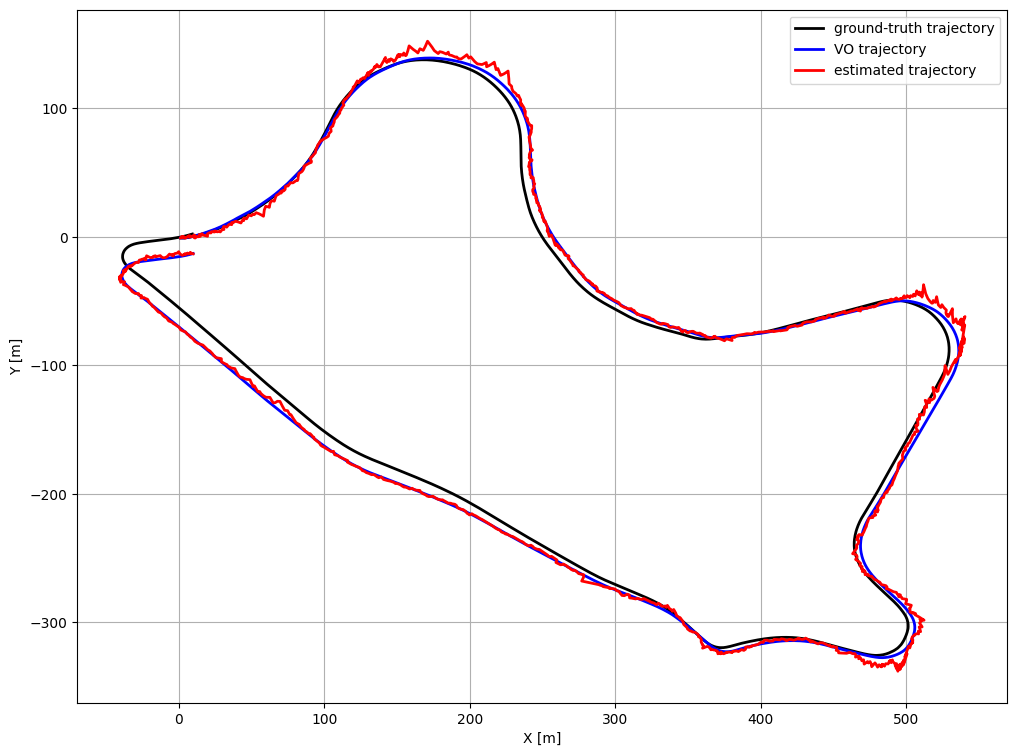

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory', color='black')

xs, ys, _ = data.VO_measurements.T
ax.plot(xs, ys, lw=2, markersize=4, alpha=1., label='VO trajectory', color='b')

ax.plot(mu_x_ukf1, mu_y_ukf1, lw=2, label='estimated trajectory', color='r')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.legend()
ax.grid()

## Setup1 Result

In [215]:
error_ukf1 = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :len(mu_x_ukf1)], np.array([mu_x_ukf1, mu_y_ukf1]))
print(f"MSE: {error_ukf1}")
errors.append(error_ukf1)

MSE: 39.462816944162114


## Setup2 (IMU input -> UKF with Visual Odometry and GPS measurement)

In [13]:
# initial values
px_, py_, pz_ = data.VO_measurements[0, :]
q1_, q2_, q3_, q4_ = data.IMU_quaterion[0]
ax_, ay_, az_ = data.IMU_acc_with_noise[0]
wx_, wy_, wz_ = data.IMU_angular_velocity_with_noise[0]

x_initial = np.array([
    [px_], #Px
    [py_], #Py
    [pz_], #Pz
    [0], #Vx
    [0], #Vy
    [0], #Vz
    [q1_], #q1
    [q2_], #q2
    [q3_], #q3
    [q4_]  #q4
])
P_initial = np.eye(x_initial.shape[0]) * 0.1
# transition matrix from predicted state vector to measurement space
# H_initial = np.array([
#     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
#     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
#     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
#     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]
# ])
H_initial = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]
])
# process noise
q0_noise, q1_noise, q2_noise, q3_noise = data.quaternion_process_noise
q_noise =  [
            1., 
            1., 
            1.,
            1., 
            1., 
            1.,
            q0_noise, 
            q1_noise, 
            q2_noise, 
            q3_noise
]
i = np.eye(len(q_noise))
Q_ = np.array([[val * num for num in i[ind]] for ind, val in enumerate(q_noise)])

# measurement noise
VO_noise_std_2 = data.VO_noise_std
GPS_measurement_noise_std_2 = data.GPS_measurement_noise_std

# R_ = np.array([
#     [VO_noise_std_2 ** 2., 0., 0., 0.],
#     [0., VO_noise_std_2 ** 2., 0., 0.],
#     [0., 0., GPS_measurement_noise_std_2 ** 2., 0.],
#     [0., 0., 0., GPS_measurement_noise_std_2 ** 2.],
# ])
R_vo = np.array([
    [VO_noise_std_2 ** 2., 0.],
    [0., VO_noise_std_2 ** 2.]
])
R_gps = np.array([
    [GPS_measurement_noise_std_2 ** 2., 0.],
    [0., GPS_measurement_noise_std_2 ** 2.]
])
# R_ = np.array([
#     [GPS_measurement_noise_std ** 2., 0.],
#     [0., GPS_measurement_noise_std ** 2.]
# ])

ukf2 = UnscentedKalmanFilter(x=x_initial, 
                             P=P_initial, 
                             H=H_initial,
                             alpha=0.6,
                             beta=6,
                             kappa=-7
                            )

In [14]:
mu_x_ukf2 = [ukf2.x[0, 0],]
mu_y_ukf2 = [ukf2.x[1, 0],]
t_last = 0.

for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt_ = t - t_last
    ax_, ay_, az_ = data.IMU_acc_with_noise[t_idx]
    wx_, wy_, wz_ = data.IMU_angular_velocity_with_noise[t_idx]
    u_ = np.array([
        ax_,
        ay_,
        az_,
        wx_,
        wy_,
        wz_
    ])
    ukf2.predict_setup1_2(u=u_, dt=dt_, Q=Q_)
    x_hat = ukf2.x.copy()
    mu_x_ukf2.append(x_hat[0, 0])
    mu_y_ukf2.append(x_hat[1, 0])
    
    # vo_z_ = data.VO_measurements_with_noise[t_idx, :2]
    # gps_z_ = data.GPS_mesurement_in_meter_with_noise[t_idx, :2]
    # ukf2.update(z=vo_z_, R=R_vo)
    # ukf2.update(z=gps_z_, R=R_gps)

    vo_z_ = data.get_vo_measurement(t_idx)
    gps_z_ = data.get_gps_measurement(t_idx)
    if vo_z_ is not None:
        ukf2.update(z=vo_z_, R=R_vo)
    if gps_z_ is not None:
        ukf2.update(z=gps_z_, R=R_gps)

    # z_ = np.concatenate([z_vo_, z_gps_]).reshape(-1, 1)
    # ukf2.update(z=z_, R=R_)
    
    # vo_z_, vo_noise_ = data.get_vo_measurement_with_noise_cov(t_idx)
    # gps_z_, gps_noise_ = data.get_gps_measurement_with_noise_cov(t_idx)
    # R_vo = np.array([
    #         [vo_noise_ ** 2., 0.],
    #         [0., vo_noise_ ** 2.],
    #     ])
    # R_gps = np.array([
    #     [gps_noise_ ** 2., 0.],
    #     [0., gps_noise_ ** 2.]
    # ])
    # ukf2.update(z=vo_z_, R=R_vo)
    # ukf2.update(z=gps_z_, R=R_gps)
    t_last = t

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2836.13it/s]


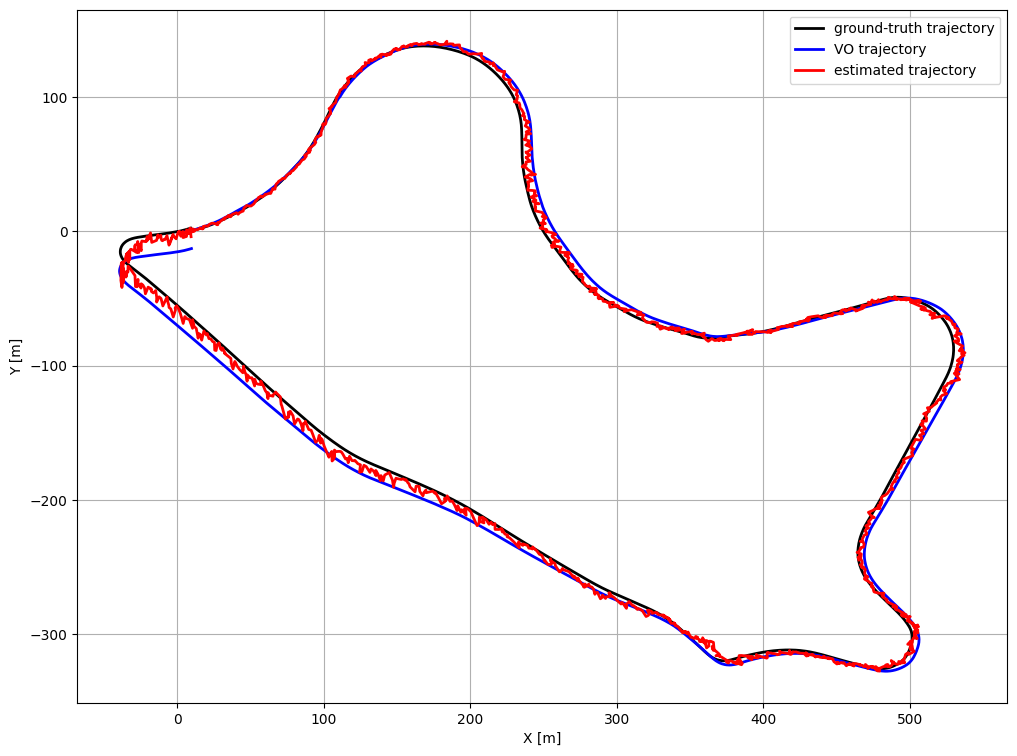

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory', color='black')

xs, ys, _ = data.VO_measurements.T
ax.plot(xs, ys, lw=2, label='VO trajectory', color='b')

ax.plot(mu_x_ukf2, mu_y_ukf2, lw=2, label='estimated trajectory', color='r')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.legend()
ax.grid()

## Setup2 Result

In [16]:
error_ukf2 = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :len(mu_x_ukf2)], np.array([mu_x_ukf2, mu_y_ukf2]))
print(f"MSE: {error_ukf2}")
errors.append(error_ukf2)

MSE: 9.452889784567612


## Setup3 (INS input -> EKF with Visual Odometry and INS measurement)

In [17]:
# state vector x
initial_x = np.array([
    data.VO_measurements[0, 0], #Px
    data.VO_measurements[0, 1], #Py
    data.IMU_outputs[0, 5]
])
initial_x = initial_x.reshape(-1, 1)

# covariance for state vector x
initial_P = np.eye(initial_x.shape[0]) * 0.1

# process noise
velocity_noise_std2 = data.velocity_noise_std
IMU_angular_velocity_noise_std2 = data.IMU_angular_velocity_noise_std
Q_ = np.array([
    [velocity_noise_std2 ** 2., 0., 0.],
    [0., velocity_noise_std2 ** 2., 0.],
    [0., 0., IMU_angular_velocity_noise_std2 ** 2.],
])

# measurement noise
VO_noise_std2 = data.VO_noise_std
GPS_measurement_noise_std2 = data.GPS_measurement_noise_std
R_vo = np.array([
    [VO_noise_std2 ** 2., 0.],
    [0., VO_noise_std2 ** 2.]
])
R_gps = np.array([
    [GPS_measurement_noise_std2 ** 2., 0.],
    [0., GPS_measurement_noise_std2 ** 2.]
])


# transition matrix H
H_ = np.array([
    [1., 0., 0.],
    [0., 1., 0.]
])

ukf3 = UnscentedKalmanFilter(x=initial_x, 
                               P=initial_P, 
                               H=H_, 
                               alpha=0.0001, 
                               beta=4., 
                               kappa=0)


In [18]:
mu_x_ukf3 = [ukf3.x[0, 0],]
mu_y_ukf3 = [ukf3.x[1, 0],]
t_last = 0.

for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt_ =  t - t_last
    vf_ = data.INS_velocities_with_noise[t_idx, 0] # forward velocity
    wz_ = data.IMU_angular_velocity_with_noise[t_idx, 2]
    u_ = np.array([
        vf_,
        wz_,
    ])
    ukf3.predict_setup3(u=u_, dt=dt_, Q=Q_)
    x_hat = ukf3.x.copy()
    mu_x_ukf3.append(x_hat[0, 0])
    mu_y_ukf3.append(x_hat[1, 0])
    # vo_z_ = data.VO_measurements_with_noise[t_idx, :2].reshape(-1, 1)
    # gps_z_ = data.GPS_mesurement_in_meter_with_noise[t_idx, :2].reshape(-1, 1)
    # ukf3.update(z=vo_z_, R=R_vo)
    # ukf3.update(z=gps_z_, R=R_gps)

    vo_z_ = data.get_vo_measurement(t_idx)
    gps_z_ = data.get_gps_measurement(t_idx)
    if vo_z_ is not None:
        ukf3.update(z=vo_z_, R=R_vo)
    if gps_z_ is not None:
        ukf3.update(z=gps_z_, R=R_gps)
    
    # vo_z_, vo_noise_ = data.get_vo_measurement_with_noise_cov(t_idx)
    # gps_z_, gps_noise_ = data.get_gps_measurement_with_noise_cov(t_idx)
    # R_vo = np.array([
    #         [vo_noise_ ** 2., 0.],
    #         [0., vo_noise_ ** 2.],
    #     ])
    # R_gps = np.array([
    #     [gps_noise_ ** 2., 0.],
    #     [0., gps_noise_ ** 2.]
    # ])
    # ukf3.update(z=vo_z_, R=R_vo)
    # ukf3.update(z=gps_z_, R=R_gps)
    t_last = t

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6660.22it/s]


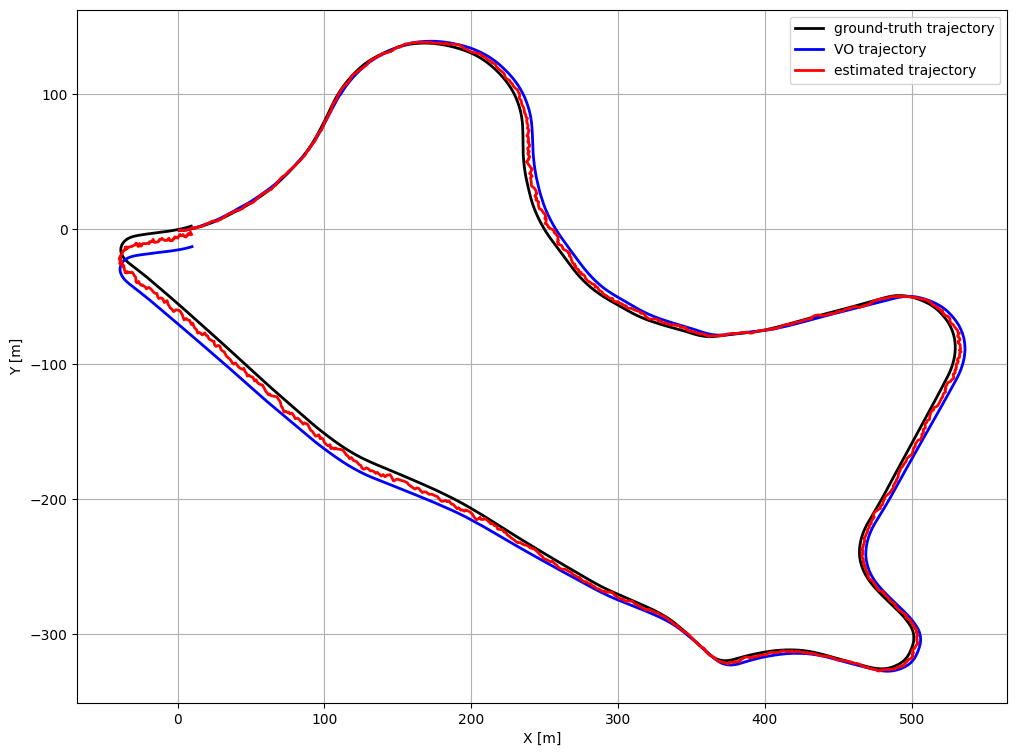

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory', color='black')

xs, ys, _ = data.VO_measurements.T
ax.plot(xs, ys, lw=2, label='VO trajectory', color='b')

ax.plot(mu_x_ukf3, mu_y_ukf3, lw=2, label='estimated trajectory', color='r')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.legend()
ax.grid()

## Setup3 Result

In [20]:
error_ukf3 = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :], np.array([mu_x_ukf3, mu_y_ukf3]))
print(f"MSE: {error_ukf3}")
errors.append(error_ukf3)

MSE: 6.758637901566904


# Result

In [21]:
error_labels = ["VO MSE error", "UKF (input:IMU, mesurement:VO)", 
                "UKF (input:IMU, measurements:VO, GPS)", "UKF (input:INS, measurements:VO, INS)"]
error_pd = pd.DataFrame(np.array(errors).reshape(1, -1), columns=error_labels)
error_pd

,VO MSE error,"UKF (input:IMU, mesurement:VO)","UKF (input:IMU, measurements:VO, GPS)","UKF (input:INS, measurements:VO, INS)"
0,29.68668,127.822819,9.45289,6.758638
